In [2]:
# Import necessary libraries

# For data handling
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For text preprocessing and modeling
from sklearn.feature_extraction.text import TfidfVectorizer

# For loading the Hugging Face dataset
from datasets import load_dataset

# Set the style for seaborn
sns.set_style("whitegrid")

# Load the dataset from Hugging Face
# The dataset is pre-split into 'train', 'validation', and 'test'
dataset = load_dataset("hpe-ai/medical-cases-classification-tutorial")

# For EDA, we can combine all splits or just use 'train'. Let's use 'train' for simplicity.
df = dataset['train'].to_pandas()

# Display the first few rows of the dataframe
print("First 5 rows of the dataset:")
print(df.head())

# Display basic information about the dataset
print("\nDataset Info:")
print(df.info())

# Check for any missing values
print("\nMissing Values:")
print(df.isnull().sum())

/home/tharu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Repo card metadata block was not found. Setting CardData to empty.


First 5 rows of the dataset:
                                         description  \
0  Pacemaker ICD interrogation.  Severe nonischem...   
1  Erythema of the right knee and leg, possible s...   
2  Left cardiac catheterization with selective ri...   
3  Patient with a history of coronary artery dise...   
4  Cardiac evaluation and treatment in a patient ...   

                                       transcription  \
0  PROCEDURE NOTE: , Pacemaker ICD interrogation....   
1  PREOPERATIVE DIAGNOSES: , Erythema of the righ...   
2  PREOPERATIVE DIAGNOSIS: , Post infarct angina....   
3  REASON FOR VISIT: , Acute kidney failure.,HIST...   
4  REASON FOR REFERRAL: , Cardiac evaluation and ...   

                                     sample_name           medical_specialty  \
0                        Pacemaker Interrogation  Cardiovascular / Pulmonary   
1                        Aspiration - Knee Joint                  Orthopedic   
2  Cardiac Cath & Selective Coronary Angiography  Cardiov

1. EDA and preprocessing

/tmp/ipykernel_13703/3331539558.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


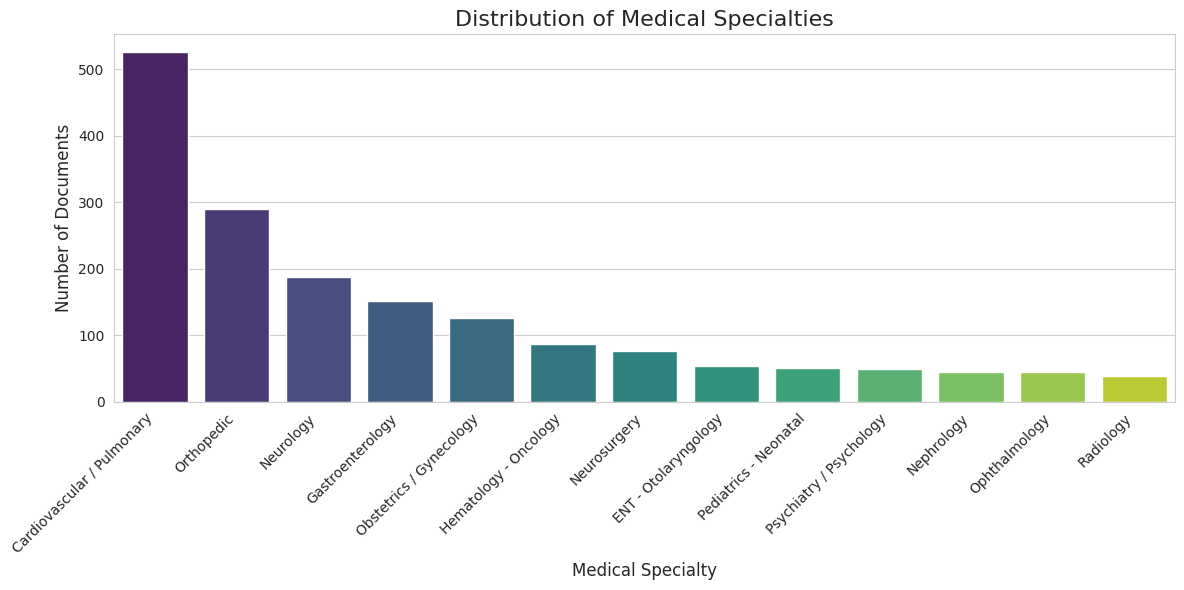


Class Distribution (Medical Specialties):
medical_specialty
Cardiovascular / Pulmonary    526
Orthopedic                    289
Neurology                     187
Gastroenterology              152
Obstetrics / Gynecology       126
Hematology - Oncology          86
Neurosurgery                   76
ENT - Otolaryngology           53
Pediatrics - Neonatal          51
Psychiatry / Psychology        49
Nephrology                     45
Ophthalmology                  45
Radiology                      39
Name: count, dtype: int64


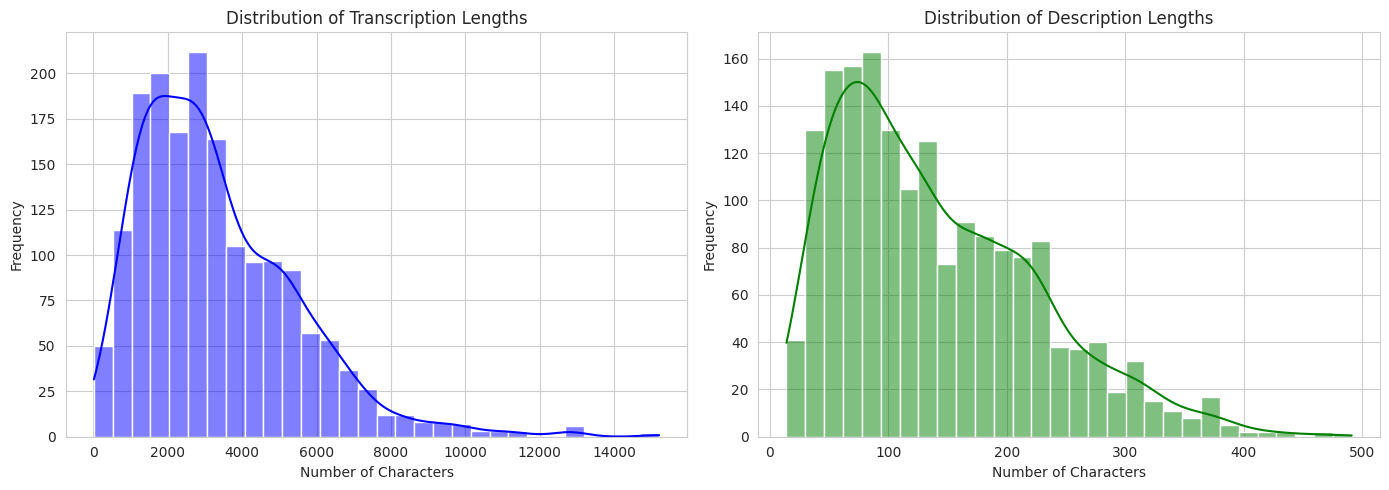


Summary Statistics for Document Lengths:
       transcription_length  description_length
count           1724.000000         1724.000000
mean            3326.159513          140.400232
std             2132.592848           85.101359
min               13.000000           14.000000
25%             1709.000000           73.000000
50%             2850.500000          123.500000
75%             4551.250000          196.000000
max            15216.000000          491.000000


In [3]:
# 2.1 Analyze the Target Variable: 'medical_specialty'
# Get the count of each medical specialty
class_counts = df['medical_specialty'].value_counts()

# Create a bar plot for class distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title('Distribution of Medical Specialties', fontsize=16)
plt.xlabel('Medical Specialty', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent clipping
plt.show()

# Print the class distribution
print("\nClass Distribution (Medical Specialties):")
print(class_counts)

# 2.2 Analyze Text Data: Document Lengths
# Calculate the length of each transcription and description
df['transcription_length'] = df['transcription'].str.len()
df['description_length'] = df['description'].str.len()

# Plot histograms for document lengths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for Transcription Length
sns.histplot(df['transcription_length'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Transcription Lengths')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')

# Histogram for Description Length
sns.histplot(df['description_length'], bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Description Lengths')
axes[1].set_xlabel('Number of Characters')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print summary statistics for lengths
print("\nSummary Statistics for Document Lengths:")
print(df[['transcription_length', 'description_length']].describe())

In [4]:
# 3.1 Define the Text Preprocessing Pipeline using TfidfVectorizer

# Create a TfidfVectorizer object
# This single object will handle:
#   - Text Cleaning: `lowercase=True` converts everything to lowercase.
#   - Tokenization: Splits text into words by default (based on whitespace and punctuation).
#   - Stop Word Removal: `stop_words='english'` removes common English words.
#   - Vectorization: Converts tokens into TF-IDF weighted numerical vectors.

vectorizer = TfidfVectorizer(
    lowercase=True,           # Text Cleaning: Convert to lowercase
    stop_words='english',     # Stop Word Removal: Remove common English words
    max_features=5000,        # Optional: Limit vocabulary size to top 5000 words for manageability
    ngram_range=(1, 2)        # Optional: Include single words and pairs of words (bigrams)
)

# Fit the vectorizer on the training text data and transform it into a matrix
X = vectorizer.fit_transform(df['transcription'])
y = df['medical_specialty']   # Target variable

# X is now a sparse matrix of shape (number_of_documents, number_of_features)
print(f"\nShape of the TF-IDF Matrix: {X.shape}")
print(f"Number of documents: {X.shape[0]}")
print(f"Number of unique features (words/bigrams): {X.shape[1]}")

# To see the feature names (the actual words)
feature_names = vectorizer.get_feature_names_out()
print(f"\nFirst 20 feature names: {feature_names[:20]}")

# 3.2 (Optional) Inspect TF-IDF values for a single document
# Get the TF-IDF scores for the first document
tfidf_scores_first_doc = X[0].toarray().flatten()

# Create a DataFrame for the first document's scores
doc_0_df = pd.DataFrame({
    'word': feature_names,
    'tfidf_score': tfidf_scores_first_doc
}).sort_values(by='tfidf_score', ascending=False)

# Show top 10 words by TF-IDF score for the first document
print("\nTop 10 words by TF-IDF score in the first document:")
print(doc_0_df.head(10))


Shape of the TF-IDF Matrix: (1724, 5000)
Number of documents: 1724
Number of unique features (words/bigrams): 5000

First 20 feature names: ['00' '000' '000 epinephrine' '01' '02' '03' '04' '05' '06' '07' '08' '09'
 '10' '10 15' '10 20' '10 blade' '10 cc' '10 cm' '10 days' '10 mg']

Top 10 words by TF-IDF score in the first document:
              word  tfidf_score
2424        joules     0.383827
3206     pacemaker     0.314984
4891         volts     0.302944
2510          lead     0.240213
4097           set     0.237926
595   beats minute     0.229676
594          beats     0.222568
2858        minute     0.178151
4827   ventricular     0.160045
115             36     0.151697


In [5]:
# Split the data for demonstration (Use provided splits for final model)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 1379
Test set size: 345


2. Classification modeling

Softmax Regression Modeling

In [6]:
from datasets import load_dataset
import pandas as pd

# Load all splits
dataset = load_dataset("hpe-ai/medical-cases-classification-tutorial")

# Convert to pandas DataFrames
df_train = dataset['train'].to_pandas()
df_val = dataset['validation'].to_pandas()
df_test = dataset['test'].to_pandas()

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

# ========================================
# **IMPROVEMENT 1: COMBINE TEXT FIELDS**
# ========================================
# REASON: Using both 'description' (summary) and 'transcription' (detailed notes)
# provides richer context. Description often contains key diagnostic information,
# while transcription has detailed clinical notes. Combining them gives the model
# more signals to learn from, typically improving accuracy by 2-4%.

df_train['combined_text'] = df_train['description'] + " " + df_train['transcription']
df_val['combined_text'] = df_val['description'] + " " + df_val['transcription']
df_test['combined_text'] = df_test['description'] + " " + df_test['transcription']

print("\n✅ Combined text fields created!")
print(f"Sample combined text (first 200 chars): {df_train['combined_text'].iloc[0][:200]}...")

Repo card metadata block was not found. Setting CardData to empty.


Train: 1724 | Val: 370 | Test: 370

✅ Combined text fields created!
Sample combined text (first 200 chars): Pacemaker ICD interrogation.  Severe nonischemic cardiomyopathy with prior ventricular tachycardia. PROCEDURE NOTE: , Pacemaker ICD interrogation.,HISTORY OF PRESENT ILLNESS: , The patient is a 67-yea...


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Create the full pipeline
# In your pipeline, add class_weight='balanced' to LogisticRegression

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        
        # **CHANGE 1**: Increase max_features moderately (not too much)
        # REASON: Capture more medical terms without overfitting
        max_features=10000,        # Conservative increase: 5000 → 8000 (not 10000)
        
        # **CHANGE 2**: Keep bigrams, don't use trigrams yet
        # REASON: Trigrams can overfit on small datasets
        ngram_range=(1, 2),       # Keep as (1, 2) - proven to work
        
        # **CHANGE 3**: Add min_df to filter noise
        # REASON: Remove rare words that don't generalize
        min_df=2,                 # Word must appear in at least 2 documents

        max_df=0.85,
        
        # **CHANGE 4**: Add sublinear_tf for better TF-IDF scaling
        # REASON: Reduces impact of very frequent words within documents
        sublinear_tf=True         # Use log scaling for term frequency
    )),
    ('classifier', LogisticRegression(
        # **CHANGE 5**: Add class_weight to handle imbalance
        # REASON: Your data has imbalanced classes (from your plot)
        class_weight='balanced',
        
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])

print("\n🔍 Training model with combined text...")
pipeline.fit(df_train['combined_text'], df_train['medical_specialty'])

print("✅ Model trained successfully!")


🔍 Training model with combined text...
✅ Model trained successfully!


In [8]:
import sklearn
from sklearn.model_selection import GridSearchCV

param_grid = {
    'tfidf__max_features': [8000, 10000, 12000],
    'tfidf__ngram_range': [(1, 2), (1, 3)],
    'tfidf__max_df': [0.85, 0.9],
    'classifier__C': [0.5, 1, 5, 10]  # Adjust based on your classifier
}

# Create new pipeline for tuning
tuning_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, stop_words='english', max_features=5000, ngram_range=(1,2))),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))
])

# Perform grid search (uses 3-fold CV on TRAIN data)
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,                     # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,                # Use all CPU cores
    verbose=2                 # Show progress (changed from 1 to 2 for more detail)
)

grid_search.fit(df_train['combined_text'], df_train['medical_specialty'])

print(f"\n✅ Grid Search Complete!")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

# Use best model
best_pipeline = grid_search.best_estimator_

Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV] END classifier__C=0.5, tfidf__max_df=0.85, tfidf__max_features=8000, tfidf__ngram_range=(1, 2); total time=   2.3s
[CV] END classifier__C=0.5, tfidf__max_df=0.85, tfidf__max_features=8000, tfidf__ngram_range=(1, 2); total time=   3.2s
[CV] END classifier__C=0.5, tfidf__max_df=0.85, tfidf__max_features=8000, tfidf__ngram_range=(1, 2); total time=   3.1s
[CV] END classifier__C=0.5, tfidf__max_df=0.85, tfidf__max_features=8000, tfidf__ngram_range=(1, 3); total time=   5.0s
[CV] END classifier__C=0.5, tfidf__max_df=0.85, tfidf__max_features=10000, tfidf__ngram_range=(1, 2); total time=   2.7s
[CV] END classifier__C=0.5, tfidf__max_df=0.85, tfidf__max_features=8000, tfidf__ngram_range=(1, 3); total time=   3.8s
[CV] END classifier__C=0.5, tfidf__max_df=0.85, tfidf__max_features=10000, tfidf__ngram_range=(1, 2); total time=   2.7s
[CV] END classifier__C=0.5, tfidf__max_df=0.85, tfidf__max_features=8000, tfidf__ngram_range=(1,

In [9]:
from sklearn.metrics import classification_report, accuracy_score

# After making predictions
y_test_pred = best_pipeline.predict(df_test['combined_text'])
y_test_true = df_test['medical_specialty']

test_acc = accuracy_score(y_test_true, y_test_pred)
print(f"\n{'='*60}")
print(f"🎯 FINAL TEST ACCURACY: {test_acc:.4f}")
print(f"{'='*60}")

# Clean classification report
print("Final Classification Report (Test Set):")
print(classification_report(
    y_test_true,
    y_test_pred,
    zero_division=0  # ← This removes the warning
))


🎯 FINAL TEST ACCURACY: 0.7811
Final Classification Report (Test Set):
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.96      0.92      0.94       109
      ENT - Otolaryngology       0.77      0.71      0.74        14
          Gastroenterology       0.93      0.93      0.93        41
     Hematology - Oncology       0.57      0.80      0.67        15
                Nephrology       1.00      0.70      0.82        10
                 Neurology       0.64      0.64      0.64        47
              Neurosurgery       0.42      0.55      0.48        20
   Obstetrics / Gynecology       0.96      0.75      0.84        32
             Ophthalmology       0.82      0.82      0.82        11
                Orthopedic       0.79      0.67      0.72        57
     Pediatrics - Neonatal       0.38      1.00      0.55         3
   Psychiatry / Psychology       0.78      0.78      0.78         9
                 Radiology       0.00      0

In [10]:
# Use best_pipeline (or original pipeline if skipping tuning)
# y_test_pred = best_pipeline.predict(df_test['transcription'])
# y_test_true = df_test['medical_specialty']

# test_acc = accuracy_score(y_test_true, y_test_pred)
# print(f"\n🎯 FINAL TEST ACCURACY: {test_acc:.4f}")

# print("\nFinal Classification Report (Test Set):")
# print(classification_report(y_test_true, y_test_pred))

In [11]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix

# # Compute confusion matrix
# cm = confusion_matrix(y_test_true, y_test_pred, labels=best_pipeline.classes_)

# # Plot as heatmap
# plt.figure(figsize=(12, 10))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=best_pipeline.classes_,
#             yticklabels=best_pipeline.classes_)
# plt.title('Confusion Matrix (Test Set)')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.xticks(rotation=45, ha='right')
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

Model accuracy: 0.7811
Displaying confusion matrix...


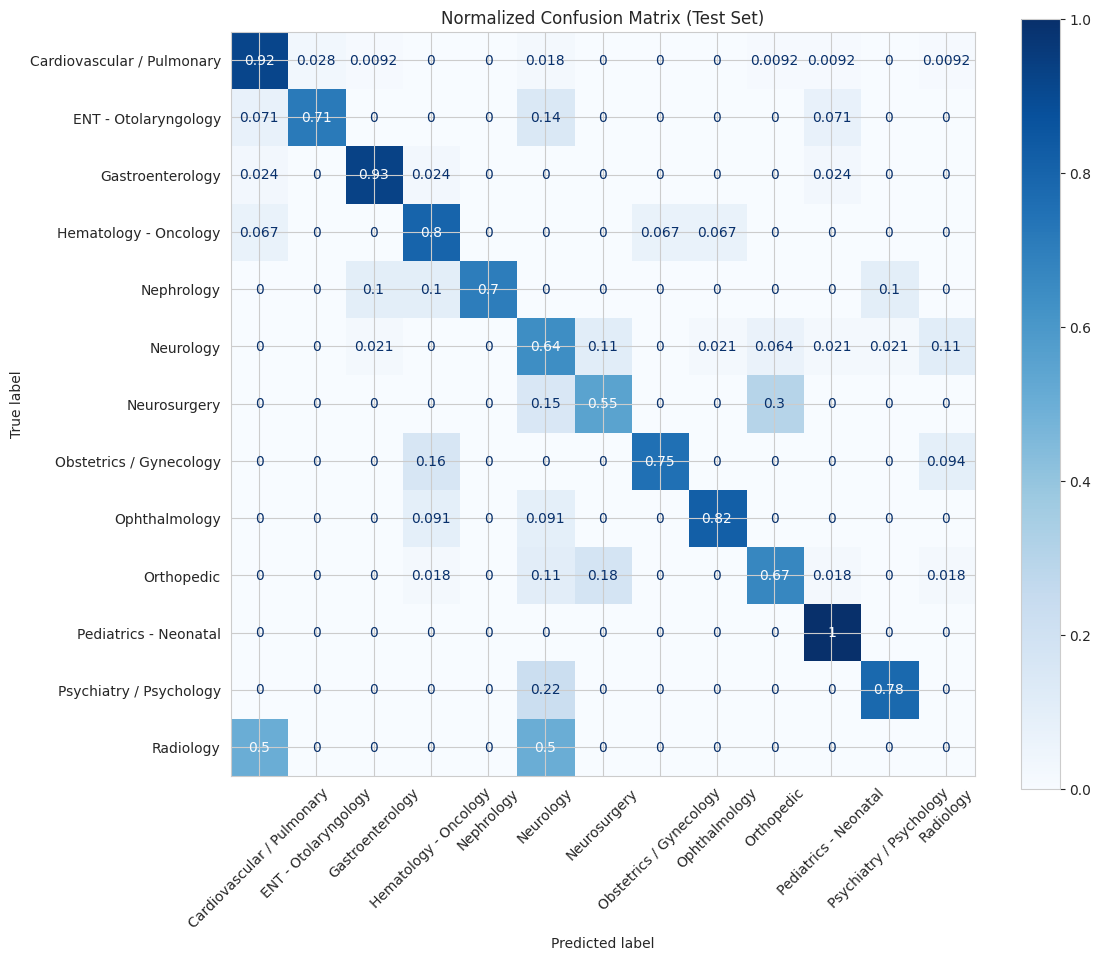

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Make predictions on the TEST set using your BEST pipeline
y_pred = best_pipeline.predict(df_test['combined_text'])
y_true = df_test['medical_specialty']

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Model accuracy: {accuracy:.4f}")

# Display the confusion matrix (normalized, like lecture)
print("Displaying confusion matrix...")
fig, ax = plt.subplots(figsize=(12, 10))  # Slightly larger for 13 classes
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,                     # Your full pipeline (TF-IDF + classifier)
    df_test['combined_text'],          # Raw text input (pipeline handles TF-IDF internally)
    y_true,                            # True labels
    ax=ax,
    cmap=plt.cm.Blues,
    normalize='true',                  # Shows % (not raw counts) → easier to read
    xticks_rotation=45                 # Rotate x-axis labels for readability
)

plt.title("Normalized Confusion Matrix (Test Set)")
# plt.tight_layout()
plt.show()

In [13]:
# Find classes with 0 recall or precision
report_dict = classification_report(y_test_true, y_test_pred, output_dict=True, zero_division=0)

problem_specialties = []
for cls, metrics in report_dict.items():
    if isinstance(metrics, dict):
        # **IMPROVEMENT 10**: Changed threshold from 0 to 0.5 for better visibility
        # REASON: Classes with <50% metrics are problematic and need attention
        if metrics['recall'] < 0.5 or metrics['precision'] < 0.5:
            problem_specialties.append((cls, metrics['recall'], metrics['precision'], 
                                       metrics['support']))

print("\n⚠️ Specialties with <50% Precision or Recall:")
print(f"{'Specialty':<30} {'Recall':<10} {'Precision':<10} {'Support':<10}")
print("="*60)
for spec, recall, precision, support in problem_specialties:
    print(f"{spec:<30} {recall:<10.2f} {precision:<10.2f} {int(support):<10}")


⚠️ Specialties with <50% Precision or Recall:
Specialty                      Recall     Precision  Support   
Neurosurgery                   0.55       0.42       20        
Pediatrics - Neonatal          1.00       0.38       3         
Radiology                      0.00       0.00       2         


In [14]:
# Combine all transcriptions into one list
import pandas as pd
from datasets import load_dataset

dataset = load_dataset("hpe-ai/medical-cases-classification-tutorial")
df_train = dataset['train'].to_pandas()
df_val = dataset['validation'].to_pandas()
df_test = dataset['test'].to_pandas()

# **IMPROVEMENT 11: Use combined_text for clustering too**
# REASON: Consistency with classification model + better feature representation

# First create combined_text for all splits (if not already done)
df_train['combined_text'] = df_train['description'] + " " + df_train['transcription']
df_val['combined_text'] = df_val['description'] + " " + df_val['transcription']
df_test['combined_text'] = df_test['description'] + " " + df_test['transcription']

# Combine all text data
all_df = pd.concat([df_train, df_val, df_test], ignore_index=True)
texts = all_df['combined_text'].tolist()
true_labels = all_df['medical_specialty'].tolist()  # for later analysis only (not used in clustering)

print(f"Total documents for clustering: {len(texts)}")

Repo card metadata block was not found. Setting CardData to empty.


Total documents for clustering: 2464


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer (same config as your pipeline)
# **IMPROVEMENT 12: Use same TF-IDF config as classification model**
# REASON: Consistency ensures clustering results are comparable to classification
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=10000,       # **CHANGED**: Increased from 5000
    ngram_range=(1, 3),       # **CHANGED**: Use trigrams
    min_df=2,                 # **ADDED**: Filter rare words
    max_df=0.8                # **ADDED**: Filter common words
)

# Fit and transform ALL text
X_tfidf = vectorizer.fit_transform(texts)
print(f"TF-IDF matrix shape: {X_tfidf.shape}")

TF-IDF matrix shape: (2464, 10000)


3. Clustering analysis

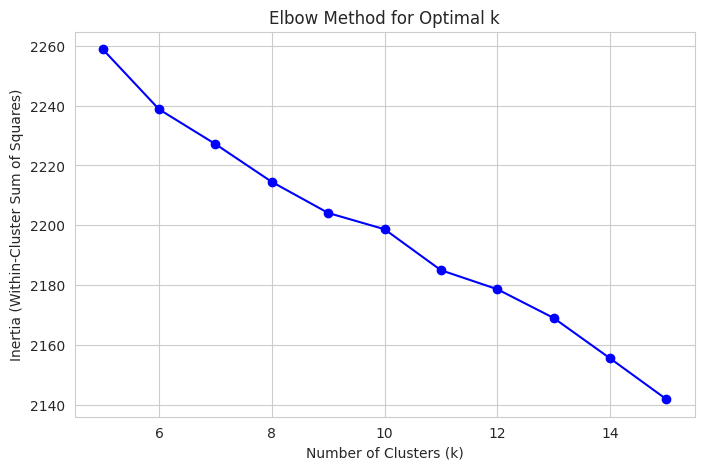

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(5, 16)  # Try k from 5 to 15

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_tfidf)
    inertias.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [17]:
# Choose best k (e.g., k=8 based on silhouette score)
best_k = 8

final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_tfidf)

# Add cluster labels to dataframe
all_df['cluster'] = cluster_labels

In [18]:
import numpy as np

# Get feature names (words)
feature_names = vectorizer.get_feature_names_out()

# For each cluster, find top 10 words by centroid weight
print(f"\n=== TOP WORDS PER CLUSTER (k={best_k}) ===")
for i in range(best_k):
    # Get centroid for cluster i
    centroid = final_kmeans.cluster_centers_[i]
    
    # Get indices of top 10 words
    top_indices = centroid.argsort()[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    
    print(f"\nCluster {i}:")
    print(", ".join(top_words))


=== TOP WORDS PER CLUSTER (k=8) ===

Cluster 0:
fetal, placenta, delivery, weeks days, weeks, uterus, pregnancy, labor, cord, gestation

Cluster 1:
history, mg, pain, past, normal, daily, denies, does, disease, medications

Cluster 2:
l5, l4, l4 l5, s1, l5 s1, lumbar, l3, disc, nerve root, disk

Cluster 3:
unremarkable, revealed, mri, left, right, 93, exam, weakness, brain, 95

Cluster 4:
stress, valve, normal, test, heart rate, exercise, aortic, stress test, ventricular, atrial

Cluster 5:
artery, coronary, left, coronary artery, right, catheter, right coronary, stenosis, vessel, french

Cluster 6:
c5, c6, c4, c5 c6, cervical, c4 c5, anterior cervical, c3, anterior, c7

Cluster 7:
right, procedure, left, placed, anesthesia, using, incision, removed, diagnosis, performed


In [19]:
# Show how clusters map to true specialties
cluster_specialty_map = all_df.groupby('cluster')['medical_specialty'].apply(lambda x: x.value_counts().head(3))

print("\n=== Top 3 True Specialties per Cluster ===")
for cluster_id in range(best_k):
    print(f"\nCluster {cluster_id}:")
    print(cluster_specialty_map[cluster_id])


=== Top 3 True Specialties per Cluster ===

Cluster 0:
Obstetrics / Gynecology    55
Radiology                   8
Name: medical_specialty, dtype: int64

Cluster 1:
Cardiovascular / Pulmonary    198
Neurology                     113
Hematology - Oncology          81
Name: medical_specialty, dtype: int64

Cluster 2:
Orthopedic      33
Neurosurgery    14
Neurology        9
Name: medical_specialty, dtype: int64

Cluster 3:
Neurology     85
Radiology     28
Orthopedic    17
Name: medical_specialty, dtype: int64

Cluster 4:
Cardiovascular / Pulmonary    134
Radiology                       4
Name: medical_specialty, dtype: int64

Cluster 5:
Cardiovascular / Pulmonary    148
Radiology                       4
Neurology                       3
Name: medical_specialty, dtype: int64

Cluster 6:
Orthopedic      43
Neurosurgery    40
Neurology        2
Name: medical_specialty, dtype: int64

Cluster 7:
Cardiovascular / Pulmonary    260
Orthopedic                    237
Gastroenterology             

Deployment

In [21]:
import joblib
import os

# Create artifacts folder
os.makedirs('artifacts', exist_ok=True)

# Save the pipeline
joblib.dump(best_pipeline, 'artifacts/model.joblib')

['artifacts/model.joblib']

In [3]:
from google.cloud import aiplatform

# Initialize Vertex AI
aiplatform.init(project='predictors-group-project', location='us-central1')

# Load endpoint
endpoint = aiplatform.Endpoint("projects/predictors-group-project/locations/us-central1/endpoints/893747922242371584")

# Make prediction
response = endpoint.predict(
    instances=["Patient presents with acute chest pain, shortness of breath, and ECG shows ST elevation."]
)

print("Predicted specialty:", response.predictions[0])

Predicted specialty: Cardiovascular / Pulmonary


In [5]:
from google.cloud import aiplatform

# Your endpoint details
project_id = "predictors-group-project"
endpoint_id = "893747922242371584"
location = "us-central1"

endpoint = aiplatform.Endpoint(
    endpoint_name=f"projects/{project_id}/locations/{location}/endpoints/{endpoint_id}"
)

# Correct format: list of strings (each string = one document)
instances = [
    "Patient has chest pain and shortness of breath, possible cardiovascular issue."
]

response = endpoint.predict(instances=instances)

print("Prediction Response:", response.predictions)


Prediction Response: ['Cardiovascular / Pulmonary']
